# Jesuit Entry (jesuita-entrada)

This notebook analysis de place of entry of the Jesuits. This corresponds normally to the college where they did their novitiate.

In [1]:
from timelink.notebooks import TimelinkNotebook

from timelink import version as timelink_version

tlnb = TimelinkNotebook()
print(f"Timelink version: {timelink_version}")

Timelink version: 1.1.26



The attribute `jesuita-entrada` records the jesuit college/noviciate
where the future missionary enrolled in the Society of Jesus.

Note that a few entries have more than one value for `jesuita-entrada`
because the person dropped out after the first enrollement and later enrolled again.

## Number of entries per location, dates

In [2]:
import pandas as pd
from timelink.pandas import attribute_values
from timelink.kleio.utilities import format_timelink_date, convert_timelink_date

# set max rows to 500
pd.set_option('display.max_rows', 500)
show_only = 30

df_totals = attribute_values('jesuita-entrada',db=tlnb.db)
# df_totals.info()
df_totals['data_inicial'] = df_totals['date_min'].apply(format_timelink_date)
df_totals['data_final'] = df_totals['date_max'].apply(format_timelink_date)
# Extract the first 4 characters of data_inicial to get the year, store in column Ano_inicial
df_totals['Ano_inicial'] = df_totals['data_inicial'].str[:4]
# Extract the first 4 characters of data_final to get the year, store in column Ano_final
df_totals['Ano_final'] = df_totals['data_final'].str[:4]
print(f"Showing only the first {show_only} rows of {df_totals.shape[0]} total rows")
df_totals[['Ano_inicial', 'Ano_final', 'data_inicial', 'data_final', 'count']].sort_values(by='count', ascending=False).head(show_only)

Showing only the first 30 rows of 67 total rows


,Ano_inicial,Ano_final,data_inicial,data_final,count
value,,,,,
?,1544,1788,1544,1788-08-28,482
Coimbra,1542,1742,1542,1742-04-27,62
Lisboa,1546,1753,1546,1753-06-12,45
Paris,1630,1759,1630-01-08,1759-03-10,41
Roma,1548,1756,1548-03-11,1756-07-09,40
Goa,1548,1736,1548,1736,33
Évora,1566,1746,1566-07-14,1746-04-05,26
Nancy,1627,1751,1627-09-29,1751-08-27,15
Macau,1628,1749,1628,1749-02-01,14


#### Export to Excel

In [3]:
df_totals.to_excel("../inferences/jesuita-entrada_totals.xlsx", sheet_name='Sheet_name_1')

## Places of entry, names, nationalities, place of birth, departure

In [4]:
import pyuca  # to sort accented characters properly
from dehergne_util import get_linked_entity_id
import pandas as pd
from timelink.pandas import entities_with_attribute
# show 500 rows
pd.set_option('display.max_rows', 550)
show_only = 10

jesuita_entrada_full: pd.DataFrame | None = entities_with_attribute(
    entity_type='person',
    show_elements=['name','groupname'],
    the_type='jesuita-entrada',
    more_attributes=['nacionalidade','nascimento', 'embarque'],
    db=tlnb.db,
)
if jesuita_entrada_full is None:
    raise ValueError("No data found for 'jesuita-entrada' attribute.")
# jesuita_entrada_full.info()


# we use the Collator class to sort the names and countries properly
# since Python does not sort accented characters properly
# we create two new columns with the sort keys
coll = pyuca.Collator()

# first we fill the NaN values with empty strings
jesuita_entrada_full['nacionalidade'] = jesuita_entrada_full['nacionalidade'].fillna('')
jesuita_entrada_full['nascimento'] = jesuita_entrada_full['nascimento'].fillna('')
jesuita_entrada_full['nascimento.comment'] = jesuita_entrada_full['nascimento.comment'].fillna('')
jesuita_entrada_full['name'] = jesuita_entrada_full['name'].fillna('?')

# now we add two columns with sort keys
jesuita_entrada_full['nacionalidade_sort'] = jesuita_entrada_full['nacionalidade'].apply(coll.sort_key)
jesuita_entrada_full['name_sort'] = jesuita_entrada_full['name'].apply(coll.sort_key)


# next we fetch wikidata Ids for place of birth and place of entty
jesuita_entrada_full['jesuita-entrada-wikidata'] = jesuita_entrada_full['jesuita-entrada.comment'].apply(get_linked_entity_id, linked_data_provider='wikidata', if_missing='no wikidata')
# same for the place of birth
jesuita_entrada_full['nascimento-wikidata'] = jesuita_entrada_full['nascimento.comment'].apply(get_linked_entity_id, linked_data_provider='wikidata', if_missing='no wikidata')
# entrada_known = jesuita_entrada_full['jesuita-entrada'] != '?'
only_n = jesuita_entrada_full.fillna('').groupname == 'n'
jesuita_entrada_full = jesuita_entrada_full[only_n]
cols=['jesuita-entrada','jesuita-entrada.date','name','nacionalidade','nascimento','nascimento.date','embarque.date']
# jesuita_entrada_full[(only_n) & (entrada_known)].sort_values(by=['jesuita-entrada','jesuita-entrada.date','name_sort','nascimento'])[cols].head(70)
print(f"Showing only the first {show_only} rows of {jesuita_entrada_full.shape[0]} total rows")
jesuita_entrada_full.sort_values(by=['jesuita-entrada.date','jesuita-entrada','name_sort','nascimento'])[cols].head(show_only)



Showing only the first 10 rows of 907 total rows


,jesuita-entrada,jesuita-entrada.date,name,nacionalidade,nascimento,nascimento.date,embarque.date
id,,,,,,,
deh-andre-fernandes-i,Ormuz,00,André Fernandes,Portugal,Campo Maior,1516,15600407
deh-pedro-de-alcacova,Coimbra,15420000,Pedro de Alcáçova,Portugal,?,15230000,NaN
deh-belchior-nunes-barreto,Coimbra,15430311,Belchior Nunes Barreto,Portugal,Porto,15190000,15510310
deh-belchior-miguel-carneiro-leitao,Coimbra,15430425,Belchior Miguel Carneiro Leitão,Portugal,Coimbra,1519,15550401
deh-francisco-perez,Coimbra,15440125,Francisco Pérez,Espanha,"Villanueva de Barcarrota, diocese de Badajoz",15140000,15460408
deh-tiburcio-de-quadros,Coimbra,15440418,Tibúrcio de Quadros,Portugal,Santarém,15280000,15550401
deh-baltasar-gago,Lisboa,1546,Baltasar Gago,Portugal,Lisboa,1515,15480317
deh-pedro-riera,Roma,15480311,Pedro Riera,Espanha,Barcelona,1526,15650325
deh-pedro-de-alcacova,Goa,15480502,Pedro de Alcáçova,Portugal,?,15230000,NaN


### Check for place on entry with no wikidata

In [5]:
# list row with "No wikidata" in the jesuita-entrada-wikidata column or nascimento-wikidata column
if jesuita_entrada_full is None:
    raise ValueError("No data found for 'jesuita-entrada' attribute.")

jesuita_entrada_full[
    (jesuita_entrada_full['jesuita-entrada-wikidata'] == 'no wikidata') &
    (jesuita_entrada_full['jesuita-entrada'] != '?')
][cols].sort_values(by=['jesuita-entrada'])[['jesuita-entrada','name']].head(10)

,jesuita-entrada,name
id,,
deh-francisco-de-oria,Ozukio (noviciado),Francisco de Oria


#### Check for birth places with no wikidata

In [6]:
# list row with "No wikidata" in the jesuita-entrada-wikidata column or nascimento-wikidata column
jesuita_entrada_full[
    (jesuita_entrada_full['nascimento-wikidata'] == 'no wikidata') &
    (jesuita_entrada_full['nascimento'] != '') &
    (jesuita_entrada_full['nascimento'] != '?')
].sort_values(by=['nascimento'])[['nascimento','nascimento-wikidata','name']]

,nascimento,nascimento-wikidata,name
id,,,
deh-claude-francois-loppin,Bellegarde,no wikidata,Claude-François Loppin
deh-joaquim-lobo,"Cadaval, diocese de Coimbra",no wikidata,Joaquim Lobo
deh-antonio-de-gouvea,"Casal, diocese de Viseu",no wikidata,António de Gouveia
deh-gaspar-ferreira,"Castrofornos, diocese de Viseu",no wikidata,Gaspar Ferreira
deh-mauro-de-azevedo,Celorico,no wikidata,Mauro de Azevedo
deh-diogo-vidal,"Cerradas, diocese de Lisboa",no wikidata,Diogo Vidal
deh-diogo-vidal,"Cerradas, diocese de Lisboa",no wikidata,Diogo Vidal
deh-simon-xavier-a-cunha-wou-li,"Changshu, Tch'ang-chou, Kiangnan",no wikidata,Simon-Xavier a Cunha Wou Li
deh-pero-rodrigues,China,no wikidata,Pero Rodrigues


## Export to Excel

In [7]:
from timelink.kleio.utilities import format_timelink_date

if jesuita_entrada_full is not None:
    jesuita_entrada_full.to_excel("../inferences/jesuitas-entrada-full.xlsx")
    # export only those with "nacionalidade" equal to "Portugal"
    jesuita_entrada_full[jesuita_entrada_full['nacionalidade'] == 'Portugal'].to_excel("../inferences/jesuitas-entrada-portugal.xlsx")
    # export only those with "nacionalidade" equal to "Portugal and jesuita-entrada = "?"
    cols = ['name','embarque.date.formated','jesuita-entrada.date.formated', 'jesuita-entrada.date.formated', 'nascimento','nascimento.date.formated','embarque.date','jesuita-entrada', 'jesuita-entrada.date', 'nascimento','nascimento.date']
    # create columns with formated dates embarque.date and jesuita-entrada.date and nascimento.date
    jesuita_entrada_full['nascimento.date.formated'] = jesuita_entrada_full['nascimento.date'].apply(format_timelink_date)
    jesuita_entrada_full['embarque.date.formated'] = jesuita_entrada_full['embarque.date'].apply(format_timelink_date)
    jesuita_entrada_full['jesuita-entrada.date.formated'] = jesuita_entrada_full['jesuita-entrada.date'].apply(format_timelink_date)

    jesuita_entrada_full[
        (jesuita_entrada_full['nacionalidade'] == 'Portugal') &
        (jesuita_entrada_full['jesuita-entrada'] == '?')
    ][cols].sort_values(["embarque.date","jesuita-entrada.date"]).to_excel("../inferences/jesuitas-entrada-portugal-unknown.xlsx")

## Analyse trends in decades

In [8]:
# extract the year from jesuita-entrada.date
jesuita_entrada_full['ano_entrada'] = jesuita_entrada_full['jesuita-entrada.date'].str[:4]
# convert 'ano_entrada' to integer
jesuita_entrada_full['ano_entrada'] = jesuita_entrada_full['ano_entrada'].astype(int)
# count ano_entrada per periods of 10 years starting from 1540
jesuita_entrada_full['periodo_entrada'] = (jesuita_entrada_full['ano_entrada'] - 1540) // 10 * 10 + 1540
# show columns jesuita-entrada.date, ano_entrada, periodo
jesuita_entrada_full[['jesuita-entrada.date','ano_entrada','periodo_entrada']].sort_values('jesuita-entrada.date').head(10)


,jesuita-entrada.date,ano_entrada,periodo_entrada
id,,,
deh-andre-fernandes-i,00,0,0
deh-pedro-de-alcacova,15420000,1542,1540
deh-belchior-nunes-barreto,15430311,1543,1540
deh-belchior-miguel-carneiro-leitao,15430425,1543,1540
deh-francisco-perez,15440125,1544,1540
deh-tiburcio-de-quadros,15440418,1544,1540
deh-baltasar-gago,1546,1546,1540
deh-pedro-riera,15480311,1548,1540
deh-pedro-de-alcacova,15480502,1548,1540


In [9]:
# count number of jesuitas-entrada per period
jesuita_entrada_full.groupby('periodo_entrada')['name'].count().reset_index().sort_values('periodo_entrada')


,periodo_entrada,name
0,0,1
1,1540,12
2,1550,25
3,1560,17
4,1570,23
5,1580,30
6,1590,26
7,1600,34
8,1610,30
9,1620,47


#### Make a graph ignoring period < 1540


In [10]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


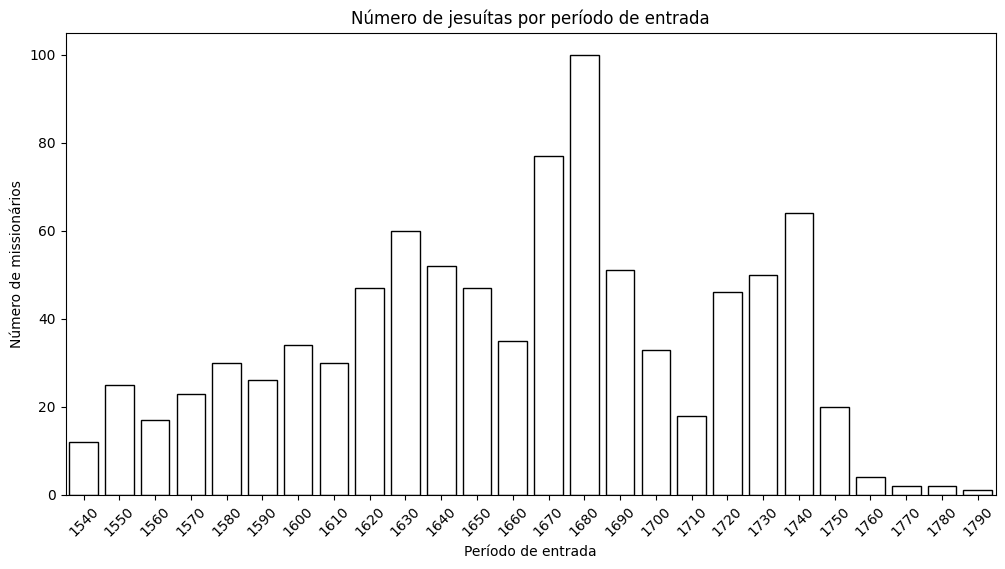

In [11]:
# make a chart of the number of jesuitas-entrada per period ignoring period < 1540
# Label the vertical axis as "Número de missionários"
# Label the horizontal axis as "Período de entrada"
import matplotlib.pyplot as plt
import seaborn as sns

# filter period >= 1540
df = jesuita_entrada_full[jesuita_entrada_full.periodo_entrada >= 1540]

# count number of jesuitas-entrada per period
df = df.groupby('periodo_entrada')['name'].count().reset_index().sort_values('periodo_entrada')

# create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='periodo_entrada', y='name', color='white', edgecolor='black')
plt.xticks(rotation=45)
plt.title('Número de jesuítas por período de entrada')

# Label the vertical axis
plt.ylabel('Número de missionários')

# Label the horizontal axis
plt.xlabel('Período de entrada')

plt.show()


### Place of entry "unkown" with country and place of birth

In [12]:
import pyuca  # to sort accented characters properly

import pandas as pd
from timelink.pandas import entities_with_attribute
# show 500 rows
pd.set_option('display.max_rows', 550)

jesuita_entrada_full = entities_with_attribute(
    entity_type='person',
    show_elements=['name','groupname'],
    the_type='jesuita-entrada',
    the_value='?',
    more_attributes=['nacionalidade','nascimento','embarque'],
    db=tlnb.db,
)
# filter by those with groupname = 'n' (avoid "referido", "pai", "mãe")
jesuita_entrada_full = jesuita_entrada_full[jesuita_entrada_full.groupname=='n']

jesuita_entrada_full.info()

coll = pyuca.Collator()

# we use the Collator class to sort the names and countries properly
# since Python does not sort accented characters properly
# we create two new columns with the sort keys

# first we fill the NaN values with empty strings
jesuita_entrada_full['nacionalidade'] = jesuita_entrada_full['nacionalidade'].fillna('?')
jesuita_entrada_full['name'] = jesuita_entrada_full['name'].fillna('?')
jesuita_entrada_full['nascimento'] = jesuita_entrada_full['nascimento'].fillna('?')

# now we add two columns with sort keys
jesuita_entrada_full['nacionalidade_sort'] = jesuita_entrada_full['nacionalidade'].apply(coll.sort_key)
jesuita_entrada_full['name_sort'] = jesuita_entrada_full['name'].apply(coll.sort_key)

cols=['name','nacionalidade','nascimento','jesuita-entrada.date','embarque.date','jesuita-entrada.obs']
jesuita_entrada_full[jesuita_entrada_full.groupname=='n'].sort_values(by=['jesuita-entrada.date', 'nacionalidade_sort','name_sort','nascimento'])[cols].head(50)



<class 'pandas.core.frame.DataFrame'>
Index: 422 entries, deh-pero-da-cruz to deh-norbert-korsak
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   name                          422 non-null    object
 1   groupname                     422 non-null    object
 2   jesuita-entrada.attr_id       422 non-null    object
 3   jesuita-entrada.type          422 non-null    object
 4   jesuita-entrada               422 non-null    object
 5   jesuita-entrada.date          422 non-null    object
 6   jesuita-entrada.line          422 non-null    int64 
 7   jesuita-entrada.level         422 non-null    int64 
 8   jesuita-entrada.obs           422 non-null    object
 9   jesuita-entrada.extra_info    422 non-null    object
 10  jesuita-entrada.date.comment  54 non-null     object
 11  jesuita-entrada.comment       13 non-null     object
 12  jesuita-entrada.original      2 non-null      object


,name,nacionalidade,nascimento,jesuita-entrada.date,embarque.date,jesuita-entrada.obs
id,,,,,,
deh-juan-baptista-de-ribera,Juan Baptista de Ribera,Espanha,Jerez de la Frontera,1554,15650325,
deh-pero-da-cruz,Pero da Cruz,Espanha,Segóvia,1554,15860411,
deh-francisco-cabral,Francisco Cabral,Portugal,"Ilha de S. Miguel, Açores",15541200,NaN,
deh-amador-da-costa,Amador da Costa,Portugal,"Ilha do Faial, Açores",15570805,15760307,
deh-diego-samaniego,Diego Samaniego,Espanha,"Talavera, diocese de Badajoz",1561,NaN,
deh-antonio-pais,António Pais,Portugal,Toreguia,15660000,NaN,
deh-diogo-pinto,Diogo Pinto,Portugal,"Quintela, diocese de Miranda",15660000,15760307,
deh-fernao-martins,Fernão Martins,Portugal,Évora,15660000,NaN,
deh-gil-martinez-de-la-mata,Gil Martínez de la Mata,Espanha,"Logroño, diocese de Calahorra",15660312,15840410,


#### Export to Excel

In [13]:
jesuita_entrada_full[cols].to_excel("../inferences/jesuitas-entrada-desc.xlsx", sheet_name='Sheet_name_1')

#### Export to text file (Portugal)

In [14]:
# Get id of interest
country_of_interest = 'Portugal'
ids = jesuita_entrada_full[jesuita_entrada_full.nacionalidade==country_of_interest].index.unique()

tlnb.db.export_as_kleio(ids,f'../inferences/jesuitas-entrada-desc-{country_of_interest}.txt')

##  Missionaries by specific place of entry in the Jesuit order

Obter os missionários por lugar de entrada na ordem


### Example/Exemplo: Coimbra

Showing palce of birth, embarque (departure).

In [15]:
place_of_entry = "Coimbra"

In [16]:
import pandas as pd
from timelink.pandas import entities_with_attribute
from dehergne_util import calc_age_at
# show 500 rows
pd.set_option('display.max_rows', 1550)

jesuita_entrada_embarque = entities_with_attribute(
    entity_type='person',
    show_elements=['name','groupname','extra_info'],
    the_type='jesuita-entrada',
    the_value=place_of_entry,
    more_attributes=['dehergne','nascimento','embarque','morte'],
    db=tlnb.db,
)

# jesuita_entrada_embarque.info()

# user only group "n"
jesuita_entrada_embarque = jesuita_entrada_embarque[jesuita_entrada_embarque.groupname=='n']

# add age at 'jesuita-entrada.date'
jesuita_entrada_embarque['age_at_entrada'] = jesuita_entrada_embarque.apply(lambda x: calc_age_at(x['nascimento.date'], x['jesuita-entrada.date']), axis=1)
# convert to int
jesuita_entrada_embarque['age_at_entrada'] = jesuita_entrada_embarque['age_at_entrada'].astype('Int64')

# add age at 'embarque.date'
jesuita_entrada_embarque['age_at_embarque'] = jesuita_entrada_embarque.apply(lambda x: calc_age_at(x['nascimento.date'], x['embarque.date']), axis=1)
# convert to int
jesuita_entrada_embarque['age_at_embarque'] = jesuita_entrada_embarque['age_at_embarque'].astype('Int64')
# years between jesuita-entrada and embarque
jesuita_entrada_embarque['entrada_to_embarque'] = jesuita_entrada_embarque['age_at_embarque'] - jesuita_entrada_embarque['age_at_entrada']

# add age at 'morte.date'
jesuita_entrada_embarque['age_at_morte'] = jesuita_entrada_embarque.apply(lambda x: calc_age_at(x['nascimento.date'], x['morte.date']), axis=1)
# convert to int
jesuita_entrada_embarque['age_at_morte'] = jesuita_entrada_embarque['age_at_morte'].astype('Int64')

# time in missions
jesuita_entrada_embarque['mission_time'] = jesuita_entrada_embarque.apply(lambda x: calc_age_at(x['embarque.date'], x['morte.date']), axis=1)
# convert to int
jesuita_entrada_embarque['mission_time'] = jesuita_entrada_embarque['mission_time'].astype('Int64')


# format dates
jesuita_entrada_embarque['nascimento.date.formated'] = jesuita_entrada_embarque['nascimento.date'].apply(format_timelink_date)
# create column with year (first 4 characters of 'nascimento.date.formated')
jesuita_entrada_embarque['nascimento.date.year'] = jesuita_entrada_embarque['nascimento.date.formated'].str[:4]

jesuita_entrada_embarque['jesuita-entrada.date.formated'] = jesuita_entrada_embarque['jesuita-entrada.date'].apply(format_timelink_date)
# create column with year
jesuita_entrada_embarque['jesuita-entrada.date.year'] = jesuita_entrada_embarque['jesuita-entrada.date.formated'].str[:4]
jesuita_entrada_embarque['embarque.date.formated'] = jesuita_entrada_embarque['embarque.date'].apply(format_timelink_date)
# create column with year
jesuita_entrada_embarque['embarque.date.year'] = jesuita_entrada_embarque['embarque.date.formated'].str[:4]

jesuita_entrada_embarque['morte.date.formated'] = jesuita_entrada_embarque['morte.date'].apply(format_timelink_date)
# create column with year
jesuita_entrada_embarque['morte.date.year'] = jesuita_entrada_embarque['morte.date.formated'].str[:4]

cols=['dehergne','name','nascimento.date.year',
            'jesuita-entrada.date.year','jesuita-entrada','age_at_entrada','entrada_to_embarque',
            'embarque.date.year','age_at_embarque',
            'morte.date.year','age_at_morte','mission_time','morte']
# remove lines with duplicate values for column 'dehergne'
jesuita_entrada_embarque = jesuita_entrada_embarque.sort_values(by=['jesuita-entrada.date.formated','embarque.date.formated']).drop_duplicates(subset=['dehergne'])
jesuita_entrada_embarque.info()
jesuita_entrada_embarque.sort_values(by=['name','jesuita-entrada.date.formated','embarque.date.formated'])[cols]


<class 'pandas.core.frame.DataFrame'>
Index: 61 entries, deh-pedro-de-alcacova to deh-inacio-pires
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   name                           61 non-null     object
 1   groupname                      61 non-null     object
 2   extra_info                     61 non-null     object
 3   jesuita-entrada.attr_id        61 non-null     object
 4   jesuita-entrada.type           61 non-null     object
 5   jesuita-entrada                61 non-null     object
 6   jesuita-entrada.date           61 non-null     object
 7   jesuita-entrada.line           61 non-null     int64 
 8   jesuita-entrada.level          61 non-null     int64 
 9   jesuita-entrada.obs            61 non-null     object
 10  jesuita-entrada.extra_info     61 non-null     object
 11  jesuita-entrada.comment        61 non-null     object
 12  jesuita-entrada.date.comment   8 non-

,dehergne,name,nascimento.date.year,jesuita-entrada.date.year,jesuita-entrada,age_at_entrada,entrada_to_embarque,embarque.date.year,age_at_embarque,morte.date.year,age_at_morte,mission_time,morte
id,,,,,,,,,,,,,
deh-adriano-pestana,631,Adriano Pestana,1617,1635,Coimbra,17,8,1643,25,,<NA>,<NA>,NaN
deh-afonso-aires,10,Afonso Aires,1630,1649,Coimbra,19,7,1657,26,1657,27,0,"[No mar, depois do Cabo da Boa Esperança]"
deh-andre-carneiro,142,André Carneiro,1650,1664,Coimbra,13,31,1694,44,1709,58,14,Goa
deh-andre-ferrao,296,André Ferrão,1625,1640,Coimbra,15,16,1657,31,1661,36,4,"Foochow (Fou-tcheou fou, Fukien)"
deh-andre-palmeiro,606,André Palmeiro,1569,1584,Coimbra,14,33,1617,47,1635,65,17,Macau
deh-antao-dantas,235,Antão Dantas,1674,1693,Coimbra,18,1,1694,19,1721,46,26,Goa
deh-antonio-gomes,370,António Gomes,1706,1725,Coimbra,18,2,1727,20,1751,44,23,Pequim
deh-antonio-lopes-junior,485,"António Lopes, júnior",1669,1684,Coimbra,15,11,1695,26,1699,29,3,Macau
deh-antonio-da-silva,768,António da Silva,1654,1669,Coimbra,15,25,1694,40,1726,72,31,Nanquim


In [17]:
# print a list of name and jesuita-entrada.date.year
place_of_entry_ids = jesuita_entrada_embarque.index.unique()
print("Number of people in the list:", len(place_of_entry_ids))
# number print rows
i = 0
for id, name,year,embarque in jesuita_entrada_embarque[['name','jesuita-entrada.date.year','embarque.date.year']].sort_values('name').itertuples(index=True):
    # print number of interactions
    i += 1
    print(f"{i:2} {name} {year}-{embarque} {id}")

Number of people in the list: 61
 1 Adriano Pestana 1635-1643 deh-adriano-pestana
 2 Afonso Aires 1649-1657 deh-afonso-aires
 3 André Carneiro 1664-1694 deh-andre-carneiro
 4 André Ferrão 1640-1657 deh-andre-ferrao
 5 André Palmeiro 1584-1617 deh-andre-palmeiro
 6 Antão Dantas 1693-1694 deh-antao-dantas
 7 António Gomes 1725-1727 deh-antonio-gomes
 8 António Lopes, júnior 1684-1695 deh-antonio-lopes-junior
 9 António da Silva 1669-1694 deh-antonio-da-silva
10 António de Almeida 1576-1584 deh-antonio-de-almeida
11 António de Andrade 1596-1600 deh-antonio-de-andrade
12 António de Gouveia 1608-1623 deh-antonio-de-gouvea
13 António de Magalhães 1692-1696 deh-antonio-de-magalhaes
14 António de Melo 1699-1715 deh-antonio-de-melo
15 Belchior Miguel Carneiro Leitão 1543-1555 deh-belchior-miguel-carneiro-leitao
16 Belchior Nunes Barreto 1543-1551 deh-belchior-nunes-barreto
17 Cristóvão da Costa 1550-1551 deh-cristovao-da-costa
18 Diogo Correia Valente 1584-1618 deh-diogo-correia-valente
19 Esta

### Analyse trends in decades for specific place of entry

In [25]:
# Extract year from jesuita-entrada.date
jesuita_entrada_embarque['ano_entrada'] = jesuita_entrada_embarque['jesuita-entrada.date'].str[:4]
# Convert 'ano_entrada' to integer
jesuita_entrada_embarque['ano_entrada'] = jesuita_entrada_embarque['ano_entrada'].astype(int)
# Count 'ano_entrada' per periods of 10 years starting from 1540
jesuita_entrada_embarque['periodo_entrada'] = (jesuita_entrada_embarque['ano_entrada'] - 1540) // 10 * 10 + 1540
# Show columns jesuita-entrada.date, ano_entrada, periodo
jesuita_entrada_embarque[['jesuita-entrada.date','ano_entrada','periodo_entrada']].sort_values('jesuita-entrada.date').head(10)


,jesuita-entrada.date,ano_entrada,periodo_entrada
id,,,
deh-pedro-de-alcacova,15420000,1542,1540
deh-belchior-nunes-barreto,15430311,1543,1540
deh-belchior-miguel-carneiro-leitao,15430425,1543,1540
deh-francisco-perez,15440125,1544,1540
deh-tiburcio-de-quadros,15440418,1544,1540
deh-goncalo-alvares,15490101,1549,1540
deh-cristovao-da-costa,15500103,1550,1550
deh-joao-rodrigues-de-sainan,1555,1555,1550
deh-pedro-martins,15560525,1556,1550


In [26]:
# count number of jesuitas-entrada per period
jesuita_entrada_embarque.groupby('periodo_entrada')['name'].count().reset_index().sort_values('periodo_entrada')

,periodo_entrada,name
0,1540,6
1,1550,3
2,1560,2
3,1570,4
4,1580,7
5,1590,5
6,1600,3
7,1610,2
8,1620,2
9,1630,3


In [27]:
# fill missing periods with 0
df_period_place_of_entry = jesuita_entrada_embarque.groupby('periodo_entrada')['name'].count().reset_index().sort_values('periodo_entrada')
df_period_place_of_entry = df_period_place_of_entry.set_index('periodo_entrada').reindex(range(1540, 1790, 10)).fillna(0).reset_index()
df_period_place_of_entry

,periodo_entrada,name
0,1540,6.0
1,1550,3.0
2,1560,2.0
3,1570,4.0
4,1580,7.0
5,1590,5.0
6,1600,3.0
7,1610,2.0
8,1620,2.0
9,1630,3.0


#### Make a graph

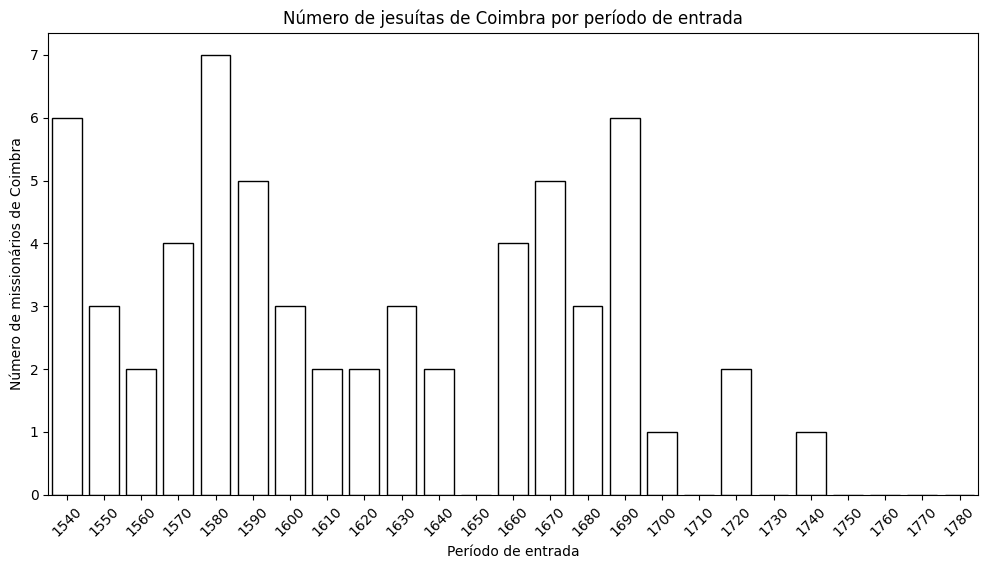

In [28]:
# make a chart of the number of jesuitas-entrada per period ignoring period < 1540
# Label the vertical axis as "Número de missionários de Coimbra"
# Label the horizontal axis as "Período de entrada"
import matplotlib.pyplot as plt
import seaborn as sns

# create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_period_place_of_entry, x='periodo_entrada', y='name', color='white', edgecolor='black')
plt.xticks(rotation=45)
plt.title(f'Número de jesuítas de {place_of_entry} por período de entrada')

# Label the vertical axis
plt.ylabel(f'Número de missionários de {place_of_entry}')

# Label the horizontal axis
plt.xlabel('Período de entrada')

plt.show()

### Export Place of Entry information

In [18]:
jesuita_entrada_embarque[cols].to_excel(f"../inferences/jesuita-entrada-{place_of_entry}.xlsx", sheet_name=f'jesuita_entrada_{place_of_entry}', index=True)

### Export to markdown


In [19]:
# pip install tabulate
%pip install tabulate


Note: you may need to restart the kernel to use updated packages.


In [31]:
import os
from pandas import DataFrame
from timelink.pandas import group_attributes as person_attributes

# create if it does not exist directory ../inferences/{place_of_entry}/markdown"
directory = f"../inferences/{place_of_entry}/markdown"
if not os.path.exists(directory):
    os.makedirs(directory)


for id, name,year,embarque in jesuita_entrada_embarque[['name','jesuita-entrada.date.year','embarque.date.year']].sort_values('name').itertuples(index=True):
    with tlnb.db.session() as session:
        p = tlnb.db.get_person(id, session=session)
        session.add(p)
        pk:str = p.to_kleio()
        pk = f"""## {name}
^[In Edit mode, select title (including the ##), right click and "Extract selection"]

---
### {name} @ timelink
```
{pk}
```

---
Select title, right click on selected title, choose extract note
"""
        fname = f"{directory}/{id}.md"
        with open(fname, 'w', encoding='utf-8') as f:
            f.write(pk)



In [32]:
jesuita_entrada_embarque.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61 entries, deh-pedro-de-alcacova to deh-inacio-pires
Data columns (total 55 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   name                           61 non-null     object
 1   groupname                      61 non-null     object
 2   extra_info                     61 non-null     object
 3   jesuita-entrada.attr_id        61 non-null     object
 4   jesuita-entrada.type           61 non-null     object
 5   jesuita-entrada                61 non-null     object
 6   jesuita-entrada.date           61 non-null     object
 7   jesuita-entrada.line           61 non-null     int64 
 8   jesuita-entrada.level          61 non-null     int64 
 9   jesuita-entrada.obs            61 non-null     object
 10  jesuita-entrada.extra_info     61 non-null     object
 11  jesuita-entrada.comment        61 non-null     object
 12  jesuita-entrada.date.comment   8 non-

In [ ]:
# export to markdown table dataframe jesuita_entrada_embarque
def df_to_markdown_table(df, cols=None):
    if cols is not None:
        df = df[cols]
    return df.to_markdown(index=True, tablefmt="pipe")
jesuita_entrada_embarque['name_link'] = jesuita_entrada_embarque['name'].apply(lambda x: f"[[{x}]]")  # obsidian style link
# update columns to include the link
cols = ['name_link', 'jesuita-entrada.date.formated', 'embarque.date.formated', 'nascimento.date.formated', 'age_at_entrada', 'age_at_embarque', 'age_at_morte', 'mission_time', 'dehergne']
markdown_table = df_to_markdown_table(jesuita_entrada_embarque, cols=cols)
# save markdown table to file
with open(f"{directory}/00_{place_of_entry}_list.md", "w") as f:
    f.write(markdown_table)

## Export people to text file as Kleio

In [23]:
tlnb.db.export_as_kleio(jesuita_entrada_embarque.index.unique(), f"../inferences/jesuita-entrada-{place_of_entry}.txt")

## Export those with place of entry originally unkown by Dehergne

Record in which the place of entry was added based on extra sources of information.

In [25]:
# List rows if '"original": "?"' is in column 'jesuita_entrada.obs'
# jesuita_entrada_comment = 'jesuita-entrada.original.comment'  # bug in timelink-py should be 'jesuita-entrada.comment'
jesuita_entrada_comment = 'jesuita-entrada.comment'  # use when bug is fixed

cols_2 = ['name','jesuita-entrada','jesuita-entrada.date','jesuita-entrada.original',jesuita_entrada_comment, 'jesuita-entrada.extra_info']
place_of_entry_extra = jesuita_entrada_embarque[jesuita_entrada_embarque['jesuita-entrada.original'] == "?"][cols_2]
place_of_entry_extra_ids = place_of_entry_extra.index.unique()
print("jesuita-entrada through extra info:",len(place_of_entry_extra_ids))
place_of_entry_extra

jesuita-entrada through extra info: 19


,name,jesuita-entrada,jesuita-entrada.date,jesuita-entrada.original,jesuita-entrada.comment,jesuita-entrada.extra_info
id,,,,,,
deh-lourenco-mexia,Lourenço Mexia,Coimbra,15600314,?,"@wikidata:Q45412 Domingues & O Neil, IV: 2645....","{'id': {'kleio_element_name': 'id', 'kleio_ele..."
deh-francisco-vieira,Francisco Vieira,Coimbra,15740200,?,"@wikidata:Q45412 Está no ""Catálogo delos Padre...","{'id': {'kleio_element_name': 'id', 'kleio_ele..."
deh-manuel-gaspar,Manuel Gaspar,Coimbra,15750926,?,"@wikidata:Q45412 Schutte, Monumenta historica ...","{'id': {'kleio_element_name': 'id', 'kleio_ele..."
deh-antonio-de-almeida,António de Almeida,Coimbra,15760104,?,"@wikidata:Q45412 ""Catálogo delos Padres y Herm...","{'id': {'kleio_element_name': 'id', 'kleio_ele..."
deh-joao-da-rocha,João da Rocha,Coimbra,1583,?,@wikidata:Q45412 Em Coimbra no ano de 1582 seg...,"{'id': {'kleio_element_name': 'id', 'kleio_ele..."
deh-mateus-de-couros,Mateus de Couros,Coimbra,15831222,?,@wikidata:Q45412 MMHM:p.94 (ARSI Japsin 35 13),"{'id': {'kleio_element_name': 'id', 'kleio_ele..."
deh-andre-palmeiro,André Palmeiro,Coimbra,15840114,?,"@wikidata:Q45412 Segundo Dominguez & O Neil, V...","{'id': {'kleio_element_name': 'id', 'kleio_ele..."
deh-sebastiao-vieira,Sebastião Vieira,Coimbra,15910203,?,"@wikidata:Q45412([Schütte, 1975, p. 1321] Seba...","{'id': {'kleio_element_name': 'id', 'kleio_ele..."
deh-manuel-dias-o-novo,"Manuel Dias, o Novo",Coimbra,15930202,?,"@wikidata:Q45412 Segungo Dominguez, J. M., & O...","{'id': {'kleio_element_name': 'id', 'kleio_ele..."


#### Save to Excel

In [26]:
place_of_entry_extra.to_excel(f"../inferences/jesuita-entrada-{place_of_entry}-extra_info.xlsx", sheet_name=f'jesuita_entrada_{place_of_entry}_extra', index=True)

Make a list

In [27]:
names_list = sorted(list(place_of_entry_extra.name))

# Join the list into a comma-separated string
comma_separated_names = ', '.join(sorted(names_list))

print(comma_separated_names)
names_list

Adriano Pestana, André Ferrão, André Palmeiro, António de Almeida, António de Gouveia, Francisco Furtado, Francisco Vieira, Gabriel de Magalhães, Gaspar do Amaral, Gonçalo da Fonseca, João da Rocha, Lourenço Mexia, Manuel Dias, o Novo, Manuel Gaspar, Mateus de Couros, Matias da Maia, Sebastião Vieira, Sebastião da Maia, Simão da Cunha


['Adriano Pestana',
 'André Ferrão',
 'André Palmeiro',
 'António de Almeida',
 'António de Gouveia',
 'Francisco Furtado',
 'Francisco Vieira',
 'Gabriel de Magalhães',
 'Gaspar do Amaral',
 'Gonçalo da Fonseca',
 'João da Rocha',
 'Lourenço Mexia',
 'Manuel Dias, o Novo',
 'Manuel Gaspar',
 'Mateus de Couros',
 'Matias da Maia',
 'Sebastião Vieira',
 'Sebastião da Maia',
 'Simão da Cunha']

#### export to text file

In [28]:

tlnb.db.export_as_kleio(place_of_entry_extra_ids, f"../inferences/jesuita-entrada-{place_of_entry}-extra_info.txt")

#### If place of entry unkown check place of entry in the birthplace 

Check for place of interest in the birth place 
of those with no record of place of entry.

Those born in the same city, district or diocesis as the place 
of entry under analysis are good candidates for further research.


In [29]:
# filter dataframe jesuita_entrada_desc for rows with place_of_entry in in column 'nascimento'
maybe = jesuita_entrada_full[jesuita_entrada_full['nascimento'].str.contains(place_of_entry, na=False)].index.unique()
jesuita_entrada_comment = 'jesuita-entrada.comment'  # use when bug is fixed

cols=['name','nacionalidade','nascimento','jesuita-entrada.date','jesuita-entrada','jesuita-entrada.original',jesuita_entrada_comment,'jesuita-entrada.obs']
maybe_place_of_entry = jesuita_entrada_full.loc[maybe]
maybe_place_of_entry.info()
maybe_place_of_entry.sort_values(by=['jesuita-entrada.date'])[cols]

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, deh-inacio-lobo to deh-jose-de-almeida-iii
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   name                          30 non-null     object
 1   groupname                     30 non-null     object
 2   jesuita-entrada.attr_id       30 non-null     object
 3   jesuita-entrada.type          30 non-null     object
 4   jesuita-entrada               30 non-null     object
 5   jesuita-entrada.date          30 non-null     object
 6   jesuita-entrada.line          30 non-null     int64 
 7   jesuita-entrada.level         30 non-null     int64 
 8   jesuita-entrada.obs           30 non-null     object
 9   jesuita-entrada.extra_info    30 non-null     object
 10  jesuita-entrada.date.comment  6 non-null      object
 11  jesuita-entrada.comment       1 non-null      object
 12  jesuita-entrada.original      0 non-null      obje

,name,nacionalidade,nascimento,jesuita-entrada.date,jesuita-entrada,jesuita-entrada.original,jesuita-entrada.comment,jesuita-entrada.obs
id,,,,,,,,
deh-inacio-lobo,Inácio Lobo,Portugal,Coimbra,1624,?,None,None,
deh-jose-estevao-de-almeida,José Estêvão de Almeida,Portugal,"Esgueira, diocese de Coimbra",16280000,?,None,None,
deh-antonio-lopes-senior,"António Lopes, sénior",Portugal,"Taveiro, diocese de Coimbra",1631,?,None,None,
deh-inacio-lobo,Inácio Lobo,Portugal,Coimbra,1635,?,None,None,
deh-luis-pinheiro,Luís Pinheiro,Portugal,"Esgueira, diocese de Coimbra",16370000,?,None,None,
deh-luis-pinheiro,Luís Pinheiro,Portugal,"Esgueira, diocese de Coimbra",16450000,?,None,None,
deh-joao-couceiro,João Couceiro,Portugal,"Tentúgal, diocese de Coimbra",1649,?,None,None,
deh-jose-soares,José Soares,Portugal,"Santa Comba Dão, diocese de Coimbra",16730300,?,None,None,
deh-antonio-simoes-i,António Simões,Portugal,"Rio de Galinhas, diocese de Coimbra",1678,?,None,None,


In [30]:
print("Number of unique ids:", maybe_place_of_entry.index.nunique())

Number of unique ids: 27


Export maybe place of entry candidates

In [31]:
maybe_place_of_entry[cols].to_excel(f"../inferences/jesuita-entrada-maybe-{place_of_entry}.xlsx", sheet_name=f'jesuita_entrada_maybe_{place_of_entry}', index=True)

Export as text file

In [32]:
tlnb.db.export_as_kleio(maybe_place_of_entry.index.unique(), f"../inferences/jesuita-entrada-maybe-{place_of_entry}.txt")

 ## Roles and tasks of missionaries from specific place of entry

In [33]:
import pandas as pd
from timelink.pandas import entities_with_attribute
# show 500 rows
pd.set_option('display.max_rows', 1550)

ids = place_of_entry_ids

roles_tasks = entities_with_attribute(
    entity_type='person',
    show_elements=['name','groupname',],
    the_type=['jesuita-cargo','jesuita-tarefa'],
    column_name='cargos_tarefas',
    more_attributes=[],
    filter_by=ids,
    db=tlnb.db,
)
# remove rows with "cargos_tarefas" NaN
roles_tasks = roles_tasks.dropna(subset=['cargos_tarefas'])
# extract the year from cargos_tarefas.date
roles_tasks['cargos_tarefas.date.year'] = roles_tasks['cargos_tarefas.date'].str[:4]

roles_tasks.info()
cols=['name','cargos_tarefas','cargos_tarefas.type','cargos_tarefas.date.year','groupname',]
# show those without date
# roles_tasks.loc[roles_tasks['cargos_tarefas.date'] == "0", cols].sort_values(['cargos_tarefas.type','cargos_tarefas','cargos_tarefas.date','name']).head(150)
roles_tasks[cols].sort_values(['cargos_tarefas.type','cargos_tarefas','cargos_tarefas.date.year']).head(150)

<class 'pandas.core.frame.DataFrame'>
Index: 178 entries, deh-francisco-vieira to deh-jose-montanha-ii
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          178 non-null    object 
 1   groupname                     178 non-null    object 
 2   cargos_tarefas.attr_id        178 non-null    object 
 3   cargos_tarefas.type           178 non-null    object 
 4   cargos_tarefas                178 non-null    object 
 5   cargos_tarefas.date           178 non-null    object 
 6   cargos_tarefas.line           178 non-null    float64
 7   cargos_tarefas.level          178 non-null    float64
 8   cargos_tarefas.obs            178 non-null    object 
 9   cargos_tarefas.extra_info     178 non-null    object 
 10  cargos_tarefas.comment        8 non-null      object 
 11  cargos_tarefas.original       13 non-null     object 
 12  cargos_tarefas.date.comment   32 

,name,cargos_tarefas,cargos_tarefas.type,cargos_tarefas.date.year,groupname
id,,,,,
deh-lourenco-mexia,Lourenço Mexia,Analista das missões da China e do Japão,jesuita-cargo,1583,n
deh-lourenco-mexia,Lourenço Mexia,Analista das missões da China e do Japão,jesuita-cargo,1584,n
deh-lourenco-mexia,Lourenço Mexia,Analista das missões da China e do Japão,jesuita-cargo,1593,n
deh-lourenco-mexia,Lourenço Mexia,Analista das missões da China e do Japão,jesuita-cargo,1596,n
deh-lourenco-mexia,Lourenço Mexia,Analista das missões da China e do Japão,jesuita-cargo,1596,n
deh-sebastiao-vieira,Sebastião Vieira,Mestre dos Noviços,jesuita-cargo,1604,n
deh-gaspar-ferreira,Gaspar Ferreira,Mestre dos Noviços,jesuita-cargo,1607,n
deh-lourenco-mexia,Lourenço Mexia,Monitor de Alessandro Valignano,jesuita-cargo,1579,n
deh-francisco-vieira,Francisco Vieira,Procurador,jesuita-cargo,0,n


#### Export to Excel

In [34]:
roles_tasks[cols].to_excel(f"../inferences/jesuita-entrada-{place_of_entry}-cargos_tarefas.xlsx", sheet_name='cargos_tarefas', index=True)

#### Get start and end dates for roles

In [35]:
roles_start_end = roles_tasks[roles_tasks['cargos_tarefas.type']=='jesuita-cargo'].groupby(['name','cargos_tarefas']).agg(
    start_date=('cargos_tarefas.date.year', 'min'),
    end_date=('cargos_tarefas.date.year', 'max')
).reset_index().sort_values(['name','cargos_tarefas','start_date',])
roles_start_end

,name,cargos_tarefas,start_date,end_date
0,André Palmeiro,Visitador das províncias de Goa e do Malabar,1621,1626
1,André Palmeiro,Visitador das províncias do Malabar,1618,1621
2,André Palmeiro,Visitador do Japão e da China,1626,1635
3,António Gomes,Vice-provincial da China,1748,1751
4,António da Silva,Reitor de Nanquim,1699,1699
5,António da Silva,Socius do bispo de Nanquim,1700,1700
6,António da Silva,Vice-provincial da China,1711,1714
7,António de Andrade,Provincial de Goa,1631,1634
8,António de Andrade,Superior de Agra,1624,1624
9,António de Andrade,Visitador de Agra,1624,1624


##### Save to Excel

In [36]:
roles_start_end.to_excel(f"../inferences/jesuita-entrada-{place_of_entry}-cargos_tarefas.datas.xlsx", sheet_name='cargos_tarefas', index=True)

#### Filter by role

In [37]:
# filter
regex = "(.*rovincial|.*Visitador|.*Superior|.*Procurador).*(China.*|Japão.*)"
roles_filtered = roles_start_end[roles_start_end.cargos_tarefas.str.contains(regex, na=False)]
roles_filtered.sort_values(['cargos_tarefas', 'start_date'])

/var/folders/gw/vd1jv7ds1hs_m54nfr94nxj80000gn/T/ipykernel_60433/863054446.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  roles_filtered = roles_start_end[roles_start_end.cargos_tarefas.str.contains(regex, na=False)]


,name,cargos_tarefas,start_date,end_date
49,Manuel Gaspar,Procurador da China e do Japão,1603,1603
51,Manuel Osório,Procurador da Província do Japão em Macau,1705,1705
38,Gonçalo da Fonseca,Procurador da Vice-província da China,1645,1660
73,Simão da Cunha,Procurador da Vice-província da China,1648,1658
60,Miguel do Amaral,Procurador da Vice-província da China,1694,1722
26,Francisco Pinto,Procurador do Japão,1717,1717
23,Francisco Pacheco,Provincial do Japão,1621,1625
71,Sebastião da Maia,Provincial do Japão,1646,1649
56,Matias da Maia,Provincial do Japão,1658,1661
61,Miguel do Amaral,Provincial do Japão,1702,1718


## Joint biography of entry in Place of interest

In [39]:
from timelink.pandas import display_group_attributes, group_attributes

ids = place_of_entry_ids

no_show=['jesuita-entrada.level','jesuita-entrada.line','dehergne','estadia@wikidata','jesuita-estatuto',
          'nome','nacionalidade','nascimento@wikidata','nome-chines','titulo','jesuita-entrada@wikidata',
          'jesuita-votos-local@wikidata',
          'wicky','wicky-viagem']

show=['jesuita-entrada','embarque','partida','chegada','estadia','cargo','jesuita-cargo','jesuita-tarefa','morte']
display_group_attributes(ids,
                    entity_type='person',
                    header_elements=['name'],
                    sort_header='jesuita-entrada.date',
                    header_attributes=['jesuita-entrada'],
                    include_attributes=show,
                    exclude_attributes=no_show,
                    sort_attributes=['the_date','the_type','the_value'],
                    db=tlnb.db,
                    category='id',
                    cmap_name='Pastel2'
                    )

,name,jesuita-entrada.type,jesuita-entrada,jesuita-entrada.date,jesuita-entrada.obs,jesuita-entrada.comment,jesuita-entrada.date.comment,jesuita-entrada.original,id
0,Pedro de Alcáçova,jesuita-entrada,Coimbra,15420000,saiu a primeira vez,@wikidata:Q45412,None,None,deh-pedro-de-alcacova
1,Belchior Nunes Barreto,jesuita-entrada,Coimbra,15430311,,@wikidata:Q45412,None,None,deh-belchior-nunes-barreto
2,Belchior Miguel Carneiro Leitão,jesuita-entrada,Coimbra,15430425,,@wikidata:Q45412,None,None,deh-belchior-miguel-carneiro-leitao
3,Francisco Pérez,jesuita-entrada,Coimbra,15440125,,@wikidata:Q45412,já é padre,None,deh-francisco-perez
4,Tibúrcio de Quadros,jesuita-entrada,Coimbra,15440418,,@wikidata:Q45412,None,None,deh-tiburcio-de-quadros
5,Gonçalo Álvares,jesuita-entrada,Coimbra,15490101,,@wikidata:Q45412,None,None,deh-goncalo-alvares
6,Cristóvão da Costa,jesuita-entrada,Coimbra,15500103,,@wikidata:Q45412,None,None,deh-cristovao-da-costa
7,João Rodrigues de Sainan,jesuita-entrada,Coimbra,1555,,@wikidata:Q45412,None,None,deh-joao-rodrigues-de-sainan
8,Pedro Martins,jesuita-entrada,Coimbra,15560525,,@wikidata:Q45412,None,None,deh-pedro-martins
9,Lourenço Mexia,jesuita-entrada,Coimbra,15600314,,"@wikidata:Q45412 Domingues & O Neil, IV: 2645. MMHM:p.226","ou 15600325 ou Coimbra, 25-03-1560 MMHM",?,deh-lourenco-mexia


,name,the_type,the_value,the_date,attr_obs,id
0,Belchior Miguel Carneiro Leitão,cargo,Patriarca da Etiópia,0,,deh-belchior-miguel-carneiro-leitao
1,Pedro Martins,cargo,Pregador do rei D. Sebastião,0,,deh-pedro-martins
2,Estanislau Machado,cargo,Vigário de vara,0,"Dehergne diz «Vicaire de vara: au sens technique actuel: vicaire forain. En réalité, il s'agit ici d'un représentant envoyé par un évêque portugais sur le territoire d'un vicaire apostolique., en somme un délégué ayant reçu des pouvoirs étendus.»",deh-estanislau-machado
3,António da Silva,cargo,Vigário de vara,0,il rejette la patente de vic. apostolique et reprend la charge de vicaire de vara,deh-antonio-da-silva
4,Francisco Pacheco,estadia,"Arima, Japão",0,prisioneiro «in odium fidei» e torturado,deh-francisco-pacheco
5,Gonçalo Álvares,estadia,Cochim,0,feito prisioneiro na região de Cochim,deh-goncalo-alvares
6,António Gomes,estadia,Diu,0,,deh-antonio-gomes
7,Manuel de Sá,estadia,Europa,0,,deh-manuel-de-sa
8,Sebastião Vieira,estadia,Filipinas,0,,deh-sebastiao-vieira
9,Miguel do Amaral,estadia,Goa,0,,deh-miguel-do-amaral
